# Baco-Pangeome of Klebsiella 

## Data Preparation

This notebook analyzes pre-extracted AnnData objects containing Bacformer protein embeddings at the gene level.

**To generate the AnnData object, run the extraction script:**

```bash
# From the workspace root
uv run python -m predict_kleb_by_bacformer.pp.extract_anndata_with_bacformer_protein_embeddings \
    --clonal-group CG258 \
    --n-samples 50 \
    --output cg258_n50_bacformer_anndata.h5ad \
    --seed 42
```

**What the extraction script does:**
- Filters metadata by clonal group (e.g., CG258)
- Randomly samples n genomes from the filtered set
- Loads Bacformer protein embeddings from PyTorch .pt files
- Explodes embeddings from sample-level to gene-level (~5000 genes per sample)
- Merges with selected metadata columns (Clonal group, Sublineage, K_locus, K_type)
- Creates AnnData object with embeddings in X and metadata in obs
- Saves to .h5ad format (~1-2GB for 20 samples)

**Memory efficiency:**
Running the extraction separately avoids memory issues on login nodes. The extraction script handles memory cleanup automatically.

In [1]:
# Imports
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import random

from pathlib import Path
from tqdm import tqdm

/home/dca36/workspace/predict_kleb_by_bacformer/.venv/lib/python3.12/site-packages/leidenalg/VertexPartition.py:388: SyntaxWarning: invalid escape sequence '\m'
  """ Implements modularity. This quality function is well-defined only for positive edge weights.
/home/dca36/workspace/predict_kleb_by_bacformer/.venv/lib/python3.12/site-packages/leidenalg/VertexPartition.py:761: SyntaxWarning: invalid escape sequence '\m'
  """ Implements Reichardt and Bornholdt's Potts model with a configuration null model.
/home/dca36/workspace/predict_kleb_by_bacformer/.venv/lib/python3.12/site-packages/leidenalg/Optimiser.py:7: SyntaxWarning: invalid escape sequence '\g'
  """ Class for doing community detection using the Leiden algorithm.
/home/dca36/workspace/predict_kleb_by_bacformer/.venv/lib/python3.12/site-packages/leidenalg/Optimiser.py:305: SyntaxWarning: invalid escape sequence '\s'
  """ Optimise the given partitions simultaneously.


In [2]:
# Load pre-extracted AnnData from .h5ad file
# This file was generated using extract_anndata_with_bacformer_protein_embeddings.py
from predict_kleb_by_bacformer.data_paths import data

anndata_dir = data.klebsiella_anndata_dir
anndata_file = anndata_dir / "cg258_n50_bacformer_anndata.h5ad"

print(f"Loading AnnData from {anndata_file}")
adata = ad.read_h5ad(anndata_file)

# Display summary information
print(f"\nLoaded AnnData with {adata.n_obs:,} observations (genes)")
print(f"Number of unique samples: {adata.obs['sample_id'].nunique()}")
print(f"Embedding dimensions: {adata.n_vars}")
print(f"\nAnnData structure:")
print(f"  - X shape: {adata.X.shape}")
print(f"  - obs shape: {adata.obs.shape}")
print(f"  - obs columns: {adata.obs.columns.tolist()}")
print(f"\nProcessing parameters:")
for key, value in adata.uns['processing_params'].items():
    print(f"  - {key}: {value}")
print(f"\nSample metadata stored in adata.uns['sample_metadata']: {adata.uns['sample_metadata'].shape}")

# Subsample the first 10 samples from KL106 and KL107 to make ratio balanced
adata_filtered = adata[adata.obs['K_locus'].isin(['KL106', 'KL107'])].copy()
# Print how many samples are in adata_filtered
print(f"Number of samples in adata_filtered: {adata_filtered.shape[0]}")
print("Cleaning up memory")
#Clean up memory
del adata
# Get unique samples and their K_locus from the sample metadata
sample_k_locus = adata_filtered.obs.groupby('sample_id')['K_locus'].first()

# Get first 10 samples from each K_locus
sampled_ids_per_k_locus = []
for k_locus in sample_k_locus.unique():
    k_locus_samples = sample_k_locus[sample_k_locus == k_locus].index.tolist()
    # Take first 10 (or all if fewer than 10)
    sampled_ids_per_k_locus.extend(k_locus_samples[:10])

print(f"Selected samples per K_locus:")
for k_locus in sample_k_locus.unique():
    k_locus_count = sum(1 for sid in sampled_ids_per_k_locus if sample_k_locus[sid] == k_locus)
    print(f"  {k_locus}: {k_locus_count} samples")

# Filter AnnData to only include genes from these samples
adata_balanced = adata_filtered[adata_filtered.obs['sample_id'].isin(sampled_ids_per_k_locus)].copy()

print(f"\nBalanced AnnData:")
print(f"  - Total observations (genes): {adata_balanced.n_obs:,}")
print(f"  - Unique samples: {adata_balanced.obs['sample_id'].nunique()}")
print(f"  - K_locus distribution:")
print(adata_balanced.obs['K_locus'].value_counts())

# Then remove the adata object from memory
print("Removing adata from memory, to free up memory, leaving the balanced AnnData object in memory")
del adata_filtered
# Reset the linked adata object so that it points to the balanced AnnData object
adata = adata_balanced

Loading AnnData from /home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/processed/klebsiella_anndata/cg258_n50_bacformer_anndata.h5ad

Loaded AnnData with 263,834 observations (genes)
Number of unique samples: 49
Embedding dimensions: 960

AnnData structure:
  - X shape: (263834, 960)
  - obs shape: (263834, 5)
  - obs columns: ['sample_id', 'Clonal group', 'Sublineage', 'K_locus', 'K_type']

Processing parameters:
  - clonal_group: CG258
  - metadata_cols: ['Clonal group' 'Sublineage' 'K_locus' 'K_type']
  - n_samples_actual: 50
  - n_samples_requested: 50
  - seed: 42

Sample metadata stored in adata.uns['sample_metadata']: (49, 157)
Number of samples in adata_filtered: 257846
Cleaning up memory
Selected samples per K_locus:
  KL107: 10 samples
  KL106: 10 samples


/tmp/ipykernel_3602240/322673504.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_k_locus = adata_filtered.obs.groupby('sample_id')['K_locus'].first()



Balanced AnnData:
  - Total observations (genes): 107,864
  - Unique samples: 20
  - K_locus distribution:
K_locus
KL107    54267
KL106    53597
Name: count, dtype: int64
Removing adata from memory, to free up memory, leaving the balanced AnnData object in memory


In [3]:
# Subsample 20 genomes - that is 20 * ~5000 = ~100,000 genes
# Get unique sample IDs and randomly sample 20
unique_sample_ids = adata.obs['sample_id'].unique().tolist()
# Subsample 20 that are all part of Clonal group CG258
cg258_samples = adata.obs[adata.obs['Clonal group'] == 'CG258']['sample_id'].unique().tolist()
cg258_genome_ids = random.sample(cg258_samples, 20)

print(f"Sampled {len(cg258_genome_ids)} genomes: {cg258_genome_ids[:5]}...")

# Subset the AnnData object to only genes from these 20 samples
adata_cg258_sampled_subset = adata[adata.obs['sample_id'].isin(cg258_genome_ids)].copy()

print(f"Subsetted AnnData shape: {adata_cg258_sampled_subset.shape}")
print(f"Number of unique samples in subset: {adata_cg258_sampled_subset.obs['sample_id'].nunique()}")

# Compute neighbors on the embedding space (X contains the 960-dim embeddings)
sc.pp.neighbors(adata_cg258_sampled_subset, n_neighbors=15, n_pcs=0)  # n_pcs=0 means use X directly

# Compute UMAP
sc.tl.umap(adata_cg258_sampled_subset)

print("UMAP computed successfully!")
print(f"UMAP coordinates shape: {adata_cg258_sampled_subset.obsm['X_umap'].shape}")

Sampled 20 genomes: ['SAMEA5976594', 'SAMEA4781355', 'SAMEA12008987', 'SAMEA6474143', 'SAMEA3727658']...
Subsetted AnnData shape: (107864, 960)
Number of unique samples in subset: 20
UMAP computed successfully!
UMAP coordinates shape: (107864, 2)


/home/dca36/workspace/predict_kleb_by_bacformer/.venv/lib/python3.12/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


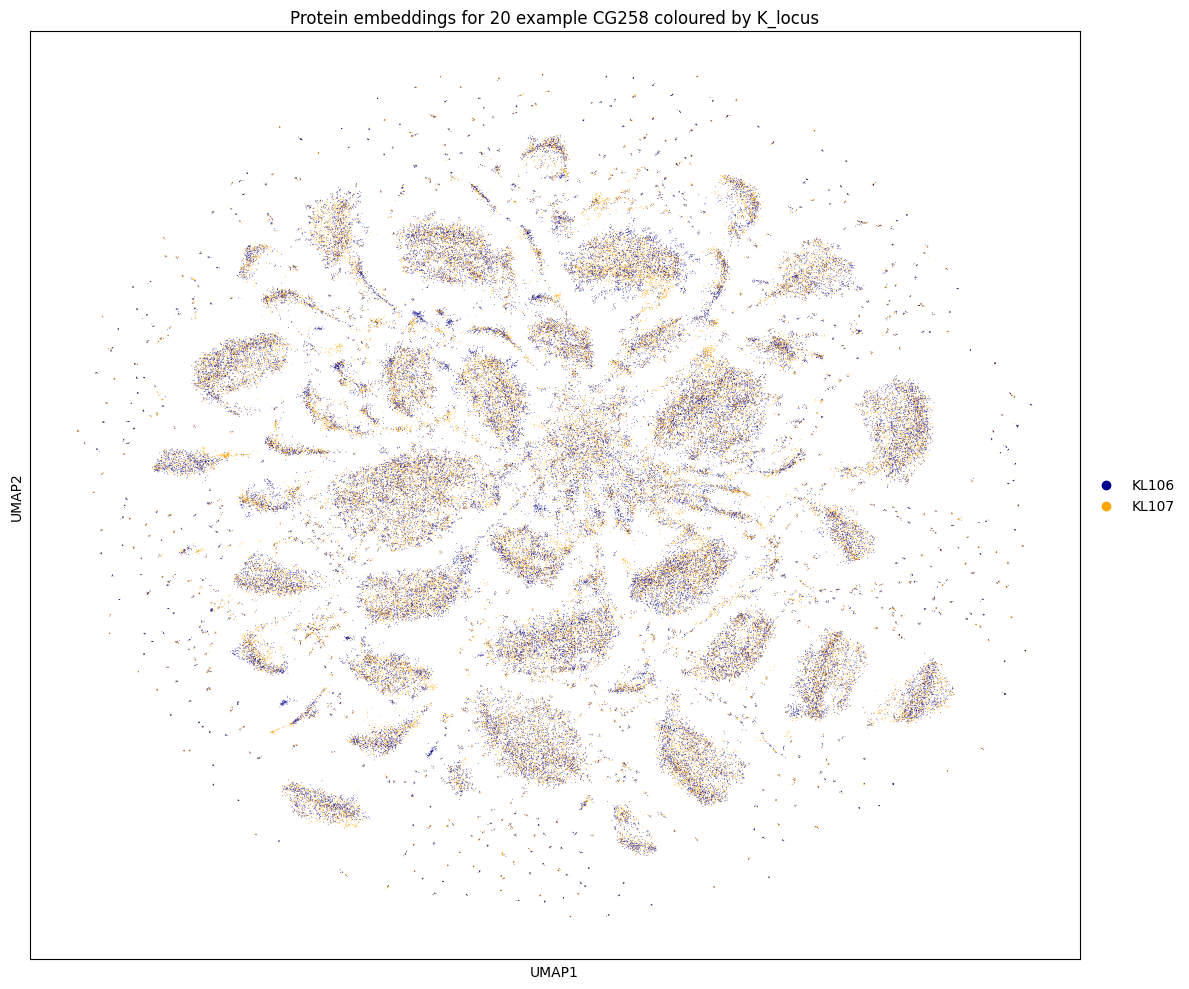


Total points plotted: 107864
Number of samples (colors): 20

K_locus distribution:
K_locus
KL107    54267
KL106    53597
Name: count, dtype: int64


In [4]:
# Plot UMAP colored by K_locus with custom colors
import matplotlib.pyplot as plt

# Define custom color palette for K_locus
k_locus_palette = {
    'KL106': 'darkblue',
    'KL107': 'orange',  # fluoro yellow (full-bright yellow)
    'KL23': 'red'
}

# Remove any K_locus = 'KL23' from the subset
adata_cg258_sampled_subset = adata_cg258_sampled_subset[adata_cg258_sampled_subset.obs['K_locus'] != 'KL23']

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Plot UMAP colored by K_locus with custom palette and set the plot title
sc.pl.umap(
    adata_cg258_sampled_subset, 
    color='K_locus', 
    palette=k_locus_palette, 
    ax=ax, 
    show=False, 
    legend_loc='right margin',
    title='Protein embeddings for 20 example CG258 coloured by K_locus'
)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nTotal points plotted: {adata_cg258_sampled_subset.shape[0]}")
print(f"Number of samples (colors): {adata_cg258_sampled_subset.obs['sample_id'].nunique()}")
print(f"\nK_locus distribution:")
print(adata_cg258_sampled_subset.obs['K_locus'].value_counts())

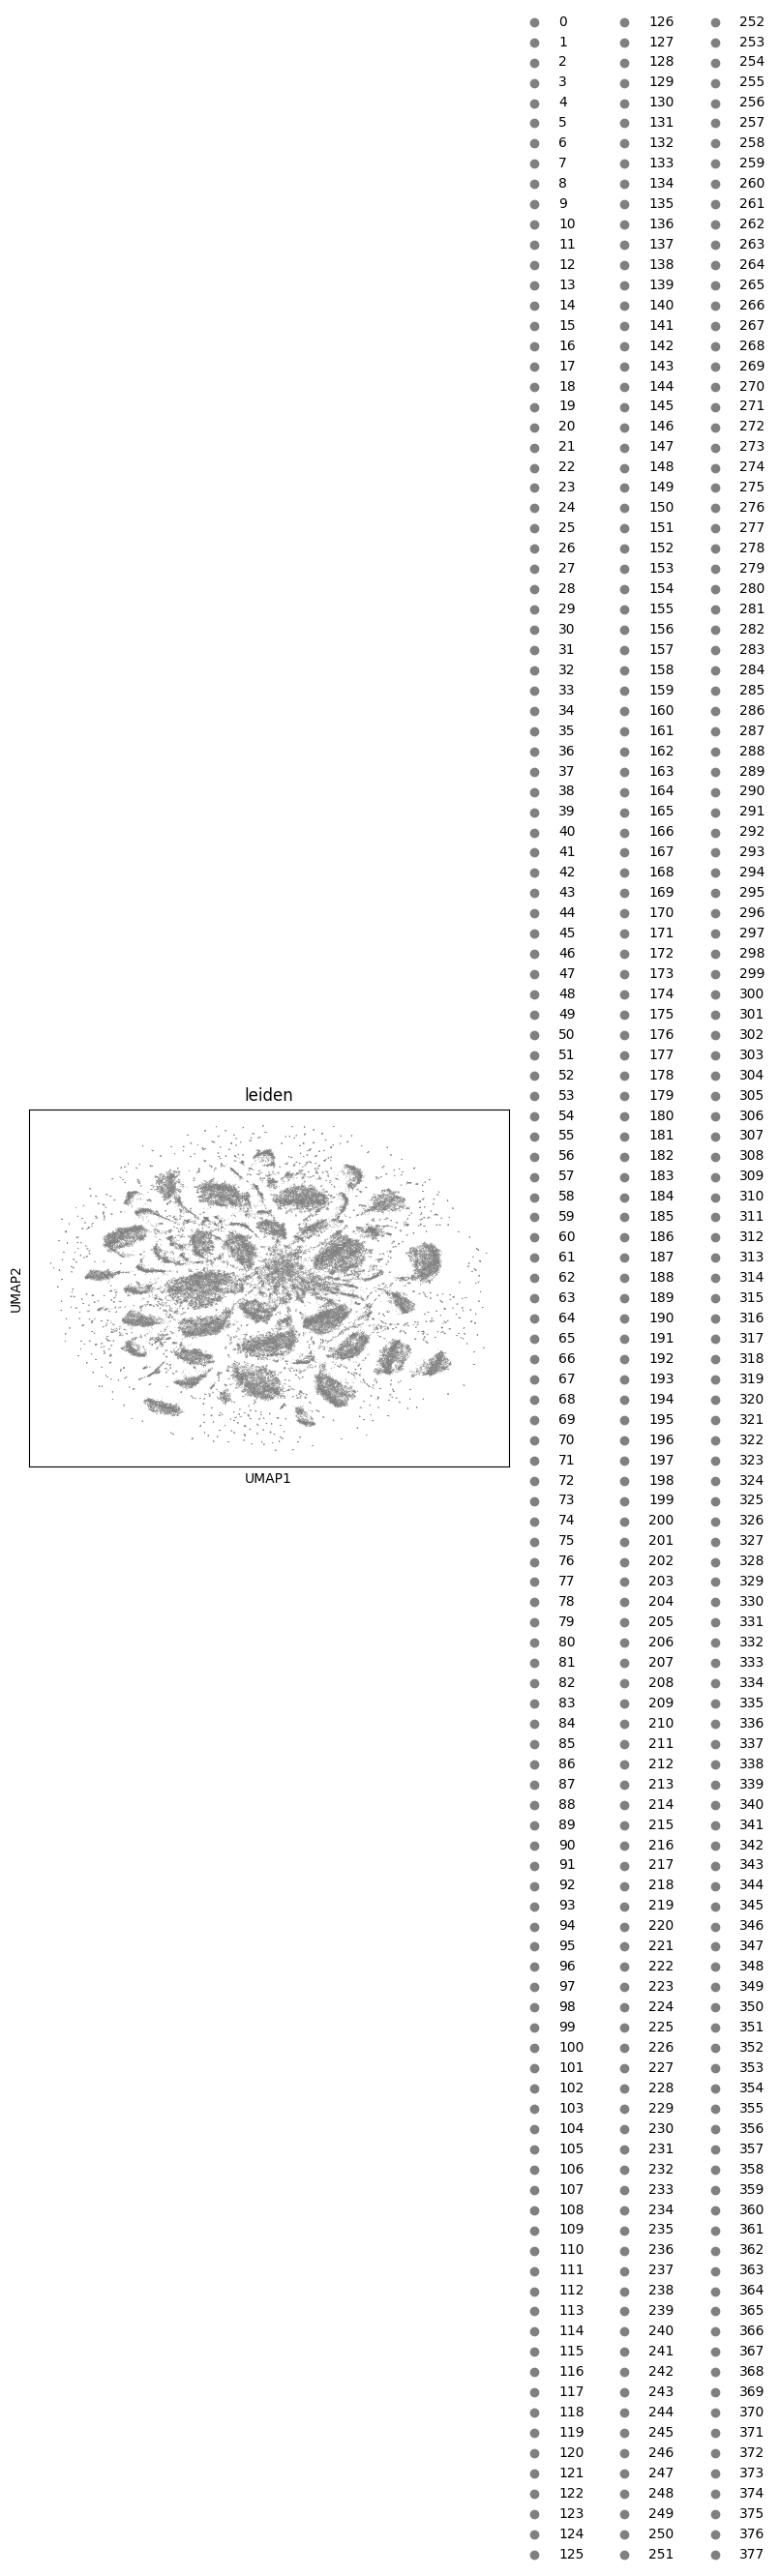

In [10]:
# Run Leiden clustering
sc.tl.leiden(adata_cg258_sampled_subset, resolution=5)

# Plot UMAP colored by leiden cluster (scanpy handles display)
sc.pl.umap(
    adata_cg258_sampled_subset,
    color='leiden'
)

In [6]:
# Get cluster assignments and K_locus annotations
cluster_klocus = pd.DataFrame({
    'cluster': adata_cg258_sampled_subset.obs['leiden'],
    'K_locus': adata_cg258_sampled_subset.obs['K_locus']
})
# Count K_locus per cluster
cluster_counts = cluster_klocus.groupby(['cluster', 'K_locus']).size().unstack(fill_value=0)

# Calculate KL106/KL107 ratio
cluster_counts['ratio'] = cluster_counts['KL106'] / cluster_counts['KL107']
cluster_counts['total'] = cluster_counts['KL106'] + cluster_counts['KL107']

# Order the clusters by ratio
cluster_counts = cluster_counts.sort_values(by='ratio', ascending=False)
# Show the top 10 clusters by ratio
display(cluster_counts.head(10))


/tmp/ipykernel_3602240/3595595764.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_counts = cluster_klocus.groupby(['cluster', 'K_locus']).size().unstack(fill_value=0)


K_locus,KL106,KL107,ratio,total
cluster,,,,
130,12,2,6.0,14
174,6,1,6.0,7
178,6,1,6.0,7
175,6,1,6.0,7
176,6,1,6.0,7
177,6,1,6.0,7
166,6,1,6.0,7
167,6,1,6.0,7
168,6,1,6.0,7


In [7]:
display(cluster_counts.tail(10))

K_locus,KL106,KL107,ratio,total
cluster,,,,
89,9,21,0.428571,30
137,3,7,0.428571,10
139,3,7,0.428571,10
136,3,7,0.428571,10
135,3,7,0.428571,10
33,303,746,0.406166,1049
78,11,29,0.379310,40
124,4,11,0.363636,15
119,4,12,0.333333,16


In [8]:
# Select clusters with extreme ratios (KL106/KL107 > 10 or < 0.1)
selected_clusters = cluster_counts[
    (cluster_counts['ratio'] >10) | (cluster_counts['ratio'] < 0.1)
].index.tolist()

print(f"Selected {len(selected_clusters)} clusters with extreme KL106/KL107 ratios:")
print(f"Cluster IDs: {selected_clusters}")

# Filter the AnnData object to only these clusters
adata_selected = adata_cg258_sampled_subset[
    adata_cg258_sampled_subset.obs['leiden'].isin(selected_clusters)
].copy()

print(f"\nFiltered data shape: {adata_selected.shape}")

Selected 0 clusters with extreme KL106/KL107 ratios:
Cluster IDs: []

Filtered data shape: (0, 960)


Overall KL106 count: 53597
Overall KL107 count: 54267
Overall ratio (KL106/KL107): 0.988
Overall log10 ratio: -0.005


KeyError: 'Could not find key log10_cluster_ratio in .var_names or .obs.columns.'

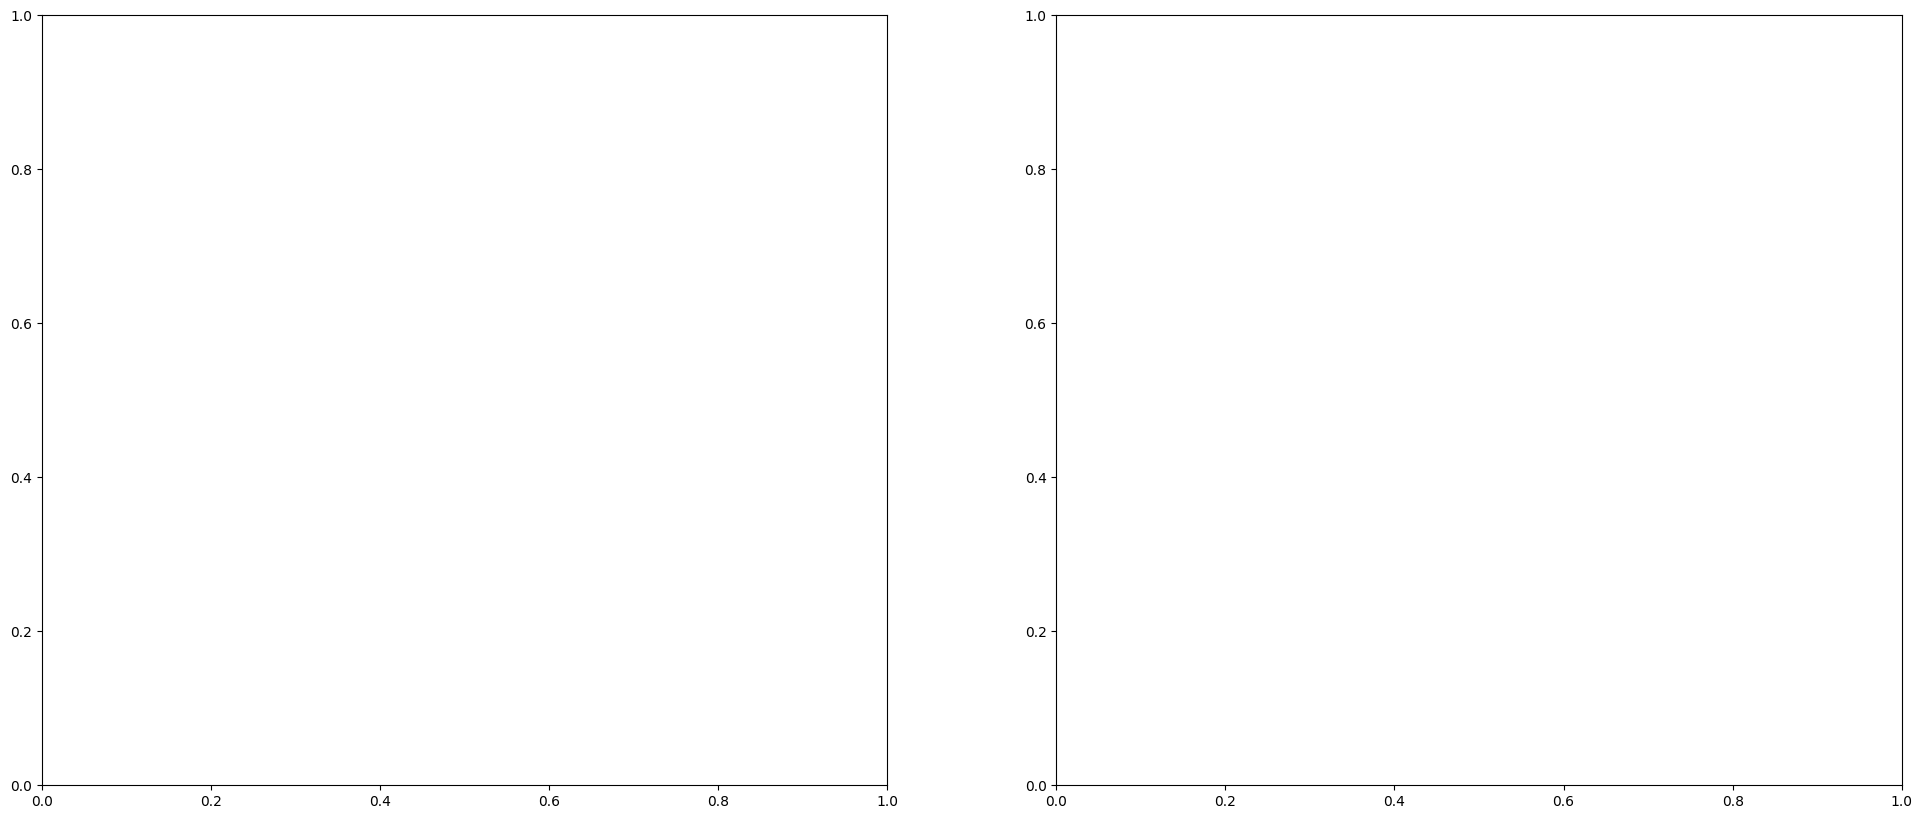

In [9]:
# Calculate the overall ratio of KL106 to KL107 in the entire dataset
overall_kl106_count = (adata_cg258_sampled_subset.obs['K_locus'] == 'KL106').sum()
overall_kl107_count = (adata_cg258_sampled_subset.obs['K_locus'] == 'KL107').sum()
overall_ratio = overall_kl106_count / overall_kl107_count
overall_log10_ratio = np.log10(overall_ratio)

print(f"Overall KL106 count: {overall_kl106_count}")
print(f"Overall KL107 count: {overall_kl107_count}")
print(f"Overall ratio (KL106/KL107): {overall_ratio:.3f}")
print(f"Overall log10 ratio: {overall_log10_ratio:.3f}")

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Left plot: UMAP colored by log10 ratio (heatmap style)
sc.pl.umap(
    adata_cg258_sampled_subset,
    color='log10_cluster_ratio',
    cmap='RdBu_r',  # Blue (KL107-dominated) to Red (KL106-dominated)
    vcenter=overall_log10_ratio,  # Center at the overall population ratio
    ax=axes[0],
    show=False,
    title=f'UMAP colored by cluster log10(KL106/KL107) ratio (centered at {overall_log10_ratio:.2f})',
    colorbar_loc='right'
)

# Create a new column to track selected vs not selected clusters
adata_cg258_sampled_subset.obs['selected_cluster'] = 'not_selected'

# Mark the selected clusters
adata_cg258_sampled_subset.obs.loc[
    adata_cg258_sampled_subset.obs['leiden'].isin(selected_clusters),
    'selected_cluster'
] = 'selected'

# Right plot: Show selected clusters (FIXED - removed groups parameter)
sc.pl.umap(
    adata_cg258_sampled_subset,
    color='selected_cluster',
    ax=axes[1],
    show=False,
    title=f'Selected Clusters with extreme ratios (n={len(selected_clusters)})',
    legend_loc='right margin'
)

plt.tight_layout()
plt.show()

In [ ]:
# Map to Panaroo genes (or gene names from Prokka) to identify the key genes differentiating each K_locus

